### 흐름
1. 환경 설정 + 데이터 로드 (BOM 처리)
2. train/test 컬럼 일관성 검증
3. 변수 분류 (카테고리 / 수치)
4. **Stratified 80/20 split** — early stopping용 검증셋 확보
5. CatBoost 학습 (메인) — `eval_metric='PRAUC'`로 직접 최적화
6. LightGBM 학습 (보조) — `metric='average_precision'`
7. 검증셋에서 **앙상블 가중치 그리드** 결정
8. **전체 train으로 재학습** (best_iter 고정) — 데이터 모두 활용
9. test 예측 + submission.csv 저장
10. **제출 형식 검증** — id 순서, 행 수, 확률값 범위 점검

## 1. 환경 설정

Colab + Drive 마운트 + 한글 폰트 + 라이브러리. CatBoost·LightGBM·Optuna는 Colab 기본 또는 빠르게 설치.

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# 한글 폰트 (그래프용)
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

# 모델링 라이브러리
!pip install -q lightgbm catboost

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
for f in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
    fm.fontManager.addfont(f)
mpl.rc('font', family='NanumGothic')
mpl.rc('axes', unicode_minus=False)

In [30]:
# 핵심 라이브러리 + 시드 고정
# - random_state=42를 모든 곳에 통일해 재현성 확보하기
# - sklearn의 train_test_split, LightGBM, CatBoost 모두 같은 시드 사용해서 통일시키기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              precision_recall_curve, roc_curve,
                              confusion_matrix, classification_report)
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', font='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
np.random.seed(SEED)

# 데이터 경로 — 본인 Drive 경로에 맞게 수정
TRAIN_PATH      = '/content/drive/MyDrive/assignment/train1.csv'
TEST_PATH       = '/content/drive/MyDrive/assignment/test1.csv'
SUBMISSION_PATH = '/content/drive/MyDrive/assignment/submission.csv'

## 2. 데이터 로드 + 컬럼 일관성 검증

### 파일이 깨져서 id 컬럼에서 error가 나길래 bom처리함

### 왜 train/test 컬럼 검증?
test에 train과 다른 컬럼이 있으면 모델이 잘못된 인덱스로 예측하는거 주의

In [31]:
def load_csv_safe(path):
    """CSV를 BOM-안전하게 로드. 첫 컬럼명의 \ufeff와 잘못 디코딩된 'ï»¿'를 제거."""
    df = pd.read_csv(path)
    df.columns = [c.replace('\ufeff', '').replace('ï»¿', '') for c in df.columns]
    return df

train = load_csv_safe(TRAIN_PATH)
test  = load_csv_safe(TEST_PATH)

# test 데이터셋에서 Late_delivery_risk 컬럼 드랍
if 'Late_delivery_risk' in test.columns:
    test = test.drop(columns=['Late_delivery_risk'])

print(f'train: {train.shape}  / test: {test.shape}')
print(f'\ntrain 컬럼 ({len(train.columns)}):')
print(list(train.columns))
print(f'\ntest 컬럼 ({len(test.columns)}):')
print(list(test.columns))

# 검증 — train에서 타깃 빼면 test와 같아야 함
train_feat = [c for c in train.columns if c != 'Late_delivery_risk']
assert train_feat == list(test.columns), \
    f"train(타깃 제외)과 test 컬럼이 다름\n train: {train_feat}\n test: {list(test.columns)}"
print('\n✓ train(타깃 제외) 컬럼 == test 컬럼')

train: (144415, 35)  / test: (36104, 34)

train 컬럼 (35):
['id', 'Type', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'order_date', 'year', 'month', 'day', 'day_of_week', 'hour', 'is_morning', 'is_america', 'product_risk_score']

test 컬럼 (34):
['id', 'Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order 

In [32]:
# 결측치·타깃 분포 점검
print('train 결측:', train.isna().sum().sum())
print('test  결측:', test.isna().sum().sum())
print(f"\n타깃 분포 (train):")
print(train['Late_delivery_risk'].value_counts(normalize=True).round(4))
print(f"\nid 중복 검사:")
print(f"  train id unique: {train['id'].is_unique}")
print(f"  test  id unique: {test['id'].is_unique}")

train 결측: 0
test  결측: 36104

타깃 분포 (train):
Late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64

id 중복 검사:
  train id unique: True
  test  id unique: True


## 3. 변수 분류

### 왜 카테고리/수치를 명시적으로 나누는가?
- LightGBM은 `categorical_feature` 파라미터로 카테고리를 native하게 처리하니까 원핫인코딩이 불필요함
- CatBoost는 `cat_features`로 같은 역할
- 잘못 분류하면 학습 시간 폭증 + 과적합

### 제외할 컬럼
- id — 식별자, 학습에 쓰면 안 됨
- Late_delivery_risk — 타깃 (y로 분리)
- order date (DateOrders), order_date — 이미 year/month/day/hour로 파생되어 있어 중복
- product_risk_score 변수 설정 오류로 제외함

In [33]:
# 학습에 쓸 수 없는 컬럼들
# DROP 컬럼:
#    id, Late_delivery_risk: 식별자/타깃
#    order date (DateOrders), order_date: 이미 year/month/day/hour로 파생됨 (중복)
#    product_risk_score
DROP_COLS = ['id', 'Late_delivery_risk',
             'order date (DateOrders)', 'order_date',
             'product_risk_score','product_risk_score']

# 카테고리로 다룰 컬럼 (모두 object dtype 또는 의미상 범주형)
CAT_COLS = [
    'Type', 'Customer Segment', 'Customer Country', 'Market', 'Department Name',
    'Category Name', 'Customer City', 'Customer State',
    'Order City', 'Order Country', 'Order Region', 'Order State',
    'Product Name',
    'day_of_week',
]

# train/test 모두에 존재하는 카테고리만 사용 (없으면 KeyError 방지)
CAT_COLS = [c for c in CAT_COLS if c in train.columns]

# 수치형 = 전체 - DROP - CAT
NUM_COLS = [c for c in train.columns
            if c not in DROP_COLS + CAT_COLS + ['Late_delivery_risk']]

print(f'카테고리 ({len(CAT_COLS)}):')
for c in CAT_COLS:
    print(f"  - {c:25s} 고유값 {train[c].nunique():>5,}")
print(f'\n수치형 ({len(NUM_COLS)}): {NUM_COLS}')

카테고리 (14):
  - Type                      고유값     4
  - Customer Segment          고유값     3
  - Customer Country          고유값     2
  - Market                    고유값     5
  - Department Name           고유값    11
  - Category Name             고유값    50
  - Customer City             고유값   563
  - Customer State            고유값    46
  - Order City                고유값 3,581
  - Order Country             고유값   164
  - Order Region              고유값    23
  - Order State               고유값 1,086
  - Product Name              고유값   118
  - day_of_week               고유값     7

수치형 (16): ['Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'year', 'month', 'day', 'hour', 'is_morning', 'is_america']


In [34]:
# X, y 분리
y_train = train['Late_delivery_risk'].values
X_train = train.drop(columns=DROP_COLS, errors='ignore')

# test는 id를 따로 보관 (제출 시 사용) + 학습 컬럼만 남김
test_ids = test['id'].values
X_test = test.drop(columns=[c for c in DROP_COLS if c in test.columns], errors='ignore')

# 컬럼 순서 일치 확인 (모델은 학습 시점 컬럼 순서를 따름)
assert list(X_train.columns) == list(X_test.columns), 'X_train, X_test 컬럼 순서 다름'
print('X_train:', X_train.shape, '/ X_test:', X_test.shape)

X_train: (144415, 30) / X_test: (36104, 30)


## 4. Stratified 80/20 split — early stopping용 검증셋

### 왜 split이 필요한가?
대회 train 전체를 그대로 fit하면 **언제까지 학습할지(best iteration)**를 모른다. iter 너무 작으면 underfit, 크면 overfit. 80/20으로 나눠 holdout PR-AUC로 best iter를 추정한 뒤, 이후 단계에서 best iter만큼 재학습시킴

### 왜 stratified인가?
타깃 비율(54.8%)을 train/valid에 똑같이 유지해서 안정적임

In [35]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=SEED,
)
print(f'X_tr {X_tr.shape}  / X_val {X_val.shape}')
print(f'pos rate  train {y_tr.mean():.4f}  valid {y_val.mean():.4f}')

X_tr (115532, 30)  / X_val (28883, 30)
pos rate  train 0.5483  valid 0.5483


## 5. CatBoost 학습 (메인 모델)

### 핵심 파라미터 의도
| 파라미터 | 값 | 이유 |
|---|---|---|
| `iterations=600` | 충분히 많이 | early stopping이 자동으로 멈춤 |
| `learning_rate=0.1` | 빠른 수렴 | 600 iter 안에 안정적 |
| `depth=8` | 깊은 트리 | 256 leaves까지 → 카테고리 분기 표현력 |
| `max_ctr_complexity=4` | **자동 카테고리 조합** | Order City × Type × is_morning × ... 4개 결합까지 — 본 데이터의 핵심 |
| `l2_leaf_reg=3` | 정규화 | 과적합 방지 |
| `eval_metric='PRAUC'` | **PR-AUC 직접 최적화** | 평가지표와 일치 |
| `od_wait=40` | early stopping patience | 40 iter 개선 없으면 멈춤 |

### CatBoost는 카테고리를 어떻게 받는가?
- 문자열 카테고리는 그대로 괜찮음
- NaN은 자동 처리되지만, 이번 데이터엔 애초에 결측이 없음
- 안전하게 모두 `astype(str)`로 통일

In [36]:
def make_catboost_pool(X, y, cat_cols):
    """CatBoost용 Pool 생성. 카테고리는 str로 강제 변환."""
    Xc = X.copy()
    for c in cat_cols:
        Xc[c] = Xc[c].astype(str)
    if y is None:
        return Pool(Xc, cat_features=cat_cols)
    return Pool(Xc, y, cat_features=cat_cols)

cat_train_pool = make_catboost_pool(X_tr,  y_tr,  CAT_COLS)
cat_valid_pool = make_catboost_pool(X_val, y_val, CAT_COLS)

cat_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    max_ctr_complexity=4,
    eval_metric='PRAUC',
    random_seed=SEED,
    verbose=100,         # 100번 반복마다 로그되게
    od_type='Iter',
    od_wait=40,
    thread_count=-1,
)
cat_model.fit(cat_train_pool, eval_set=cat_valid_pool, use_best_model=True)

# valid 예측 + 점수
proba_cat_val = cat_model.predict_proba(make_catboost_pool(X_val, None, CAT_COLS))[:, 1]
prauc_cat = average_precision_score(y_val, proba_cat_val)
rocauc_cat = roc_auc_score(y_val, proba_cat_val)
cat_best_iter = cat_model.tree_count_

print(f'\n[CatBoost] PR-AUC={prauc_cat:.4f}  ROC-AUC={rocauc_cat:.4f}  best_iter={cat_best_iter}')

0:	learn: 0.8527440	test: 0.9268950	best: 0.9268950 (0)	total: 721ms	remaining: 7m 11s
100:	learn: 0.9077614	test: 0.9708791	best: 0.9708915 (94)	total: 48.8s	remaining: 4m 1s
200:	learn: 0.9201454	test: 0.9752539	best: 0.9752596 (198)	total: 1m 27s	remaining: 2m 54s
300:	learn: 0.9278165	test: 0.9758168	best: 0.9758248 (298)	total: 2m 9s	remaining: 2m 9s
400:	learn: 0.9345064	test: 0.9766414	best: 0.9766553 (387)	total: 2m 50s	remaining: 1m 24s
500:	learn: 0.9404792	test: 0.9768541	best: 0.9768541 (500)	total: 3m 31s	remaining: 41.8s
599:	learn: 0.9463556	test: 0.9770951	best: 0.9771097 (596)	total: 4m 11s	remaining: 0us

bestTest = 0.977109688
bestIteration = 596

Shrink model to first 597 iterations.

[CatBoost] PR-AUC=0.9771  ROC-AUC=0.9716  best_iter=597


## 6. LightGBM 학습 (보조 모델)

### 왜 LightGBM도 쓰냐
- CatBoost와 다른 알고리즘 → 같은 데이터를 "다르게 본다" → 앙상블 시 보완 즉 다른 관점도 볼 수 있음
- 단독 점수는 CatBoost보다 낮지만(검증 0.95 vs 0.98), 가중 평균에서 더 좋은 결과를 나타낼 수도 있으니까

### 카테고리 처리 핵심 — Train↔Test 카테고리 정렬
```python
X_test[c] = pd.Categorical(X_test[c], categories=X_train[c].cat.categories)
```
이 한 줄이 결정적. test의 카테고리 순서가 train과 다르면 같은 도시가 다른 인덱스로 인식돼 점수가 박살난다. 앞서 얘기한 train과 test가 같아야 한다는 말의 연장선

In [37]:
def to_lgb_categorical(X_ref, X_apply, cat_cols):
    """Train의 cat 카테고리 순서를 Test에도 동일 적용."""
    Xa = X_apply.copy()
    for c in cat_cols:
        if c not in X_ref.columns:
            continue
        ref = X_ref[c].astype('category')
        Xa[c] = pd.Categorical(Xa[c], categories=ref.cat.categories)
    return Xa

# X_tr 자체에도 cat dtype 적용
X_tr_lgb  = X_tr.copy()
for c in CAT_COLS:
    X_tr_lgb[c] = X_tr_lgb[c].astype('category')

# X_val/X_test는 X_tr 기준으로 정렬
X_val_lgb  = to_lgb_categorical(X_tr_lgb, X_val,  CAT_COLS)
X_test_lgb = to_lgb_categorical(X_tr_lgb, X_test, CAT_COLS)

dtrain = lgb.Dataset(X_tr_lgb,  y_tr,  categorical_feature=CAT_COLS)
dvalid = lgb.Dataset(X_val_lgb, y_val, categorical_feature=CAT_COLS, reference=dtrain)

# Optuna로 찾았던 좋은 파라미터
lgb_params = {
    'objective':       'binary',
    'metric':          'average_precision',  # PR-AUC 직접 최적화
    'learning_rate':   0.05,
    'num_leaves':      255,                  # 깊은 트리 (CatBoost depth=8 ≈ 256 leaves)
    'min_data_in_leaf': 20,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq':    5,
    'lambda_l2':       1.0,
    'cat_smooth':      10,                   # 카테고리 분기 평활
    'cat_l2':          10,                   # 카테고리 정규화
    'verbose':         -1,
    'seed':            SEED,
}

lgb_model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dvalid],
    valid_names=['valid'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
) #여기서도 100번마다 로그되게

proba_lgb_val = lgb_model.predict(X_val_lgb)
prauc_lgb = average_precision_score(y_val, proba_lgb_val)
rocauc_lgb = roc_auc_score(y_val, proba_lgb_val)
lgb_best_iter = lgb_model.best_iteration

print(f'\n[LightGBM] PR-AUC={prauc_lgb:.4f}  ROC-AUC={rocauc_lgb:.4f}  best_iter={lgb_best_iter}')

Training until validation scores don't improve for 50 rounds
[100]	valid's average_precision: 0.831978
[200]	valid's average_precision: 0.888285
[300]	valid's average_precision: 0.91177
[400]	valid's average_precision: 0.924812
[500]	valid's average_precision: 0.93243
[600]	valid's average_precision: 0.937329
[700]	valid's average_precision: 0.940954
[800]	valid's average_precision: 0.943318
[900]	valid's average_precision: 0.945329
[1000]	valid's average_precision: 0.947059
[1100]	valid's average_precision: 0.948331
[1200]	valid's average_precision: 0.94937
[1300]	valid's average_precision: 0.950282
[1400]	valid's average_precision: 0.951323
[1500]	valid's average_precision: 0.952138
[1600]	valid's average_precision: 0.952649
[1700]	valid's average_precision: 0.953127
[1800]	valid's average_precision: 0.953698
[1900]	valid's average_precision: 0.954157
[2000]	valid's average_precision: 0.954789
Did not meet early stopping. Best iteration is:
[2000]	valid's average_precision: 0.954789


## 7. 앙상블 가중치 결정

### 왜 그리드 서치인가?
11개 가중치(0.0 ~ 1.0, 0.1 step)에서 valid PR-AUC 최대값 선택.

 w_lgb  PR-AUC
   0.0  0.9771
   0.1  0.9785
   0.2  0.9792
   0.3  0.9794
   0.4  0.9792
   0.5  0.9786
   0.6  0.9776
   0.7  0.9761
   0.8  0.9739
   0.9  0.9699
   1.0  0.9548

>>> best w_lgb = 0.3  →  valid PR-AUC = 0.9794


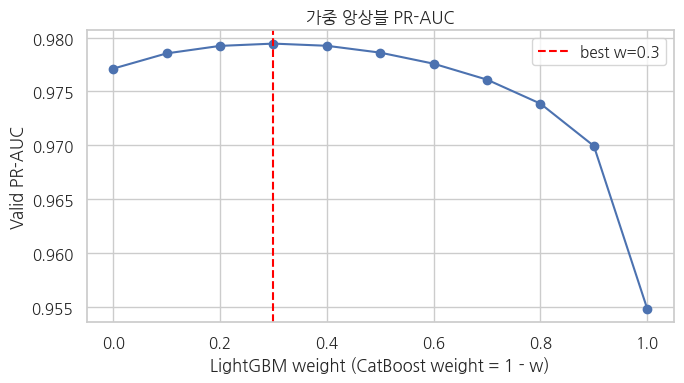

In [38]:
# 가중치 그리드
records = []
for w in np.arange(0.0, 1.01, 0.1):
    p = w * proba_lgb_val + (1 - w) * proba_cat_val
    records.append({
        'w_lgb': round(w, 1),
        'PR-AUC': average_precision_score(y_val, p),
    })
weight_df = pd.DataFrame(records)
print(weight_df.round(4).to_string(index=False))

best_row = weight_df.loc[weight_df['PR-AUC'].idxmax()]
W_LGB = float(best_row['w_lgb'])
print(f"\n>>> best w_lgb = {W_LGB:.1f}  →  valid PR-AUC = {best_row['PR-AUC']:.4f}")

# 시각화 : 0.3일때가 가장 좋더라
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weight_df['w_lgb'], weight_df['PR-AUC'], marker='o')
ax.axvline(W_LGB, ls='--', c='red', label=f'best w={W_LGB:.1f}')
ax.set_xlabel('LightGBM weight (CatBoost weight = 1 - w)')
ax.set_ylabel('Valid PR-AUC')
ax.set_title('가중 앙상블 PR-AUC')
ax.legend(); plt.tight_layout(); plt.show()

## 8. 전체 train으로 재학습 — best_iter 고정

### 왜 재학습?
80/20에서 검증한 best_iter는 "train의 80%만 본 모델의 최적값". 마지막 20%(28,883행)도 학습에 활용하면 점수가 추가 향상될 수 있다.

### 어떻게?
- early stopping 없이 **`iterations=cat_best_iter`로 고정**
- `eval_set` 제거 (검증셋 없음)
- 단, 보통 전체 데이터를 학습하므로 best_iter를 약간 늘려서 설정 데이터가 늘어나면 underfit 위험 .. 단순화를 위해 best_iter 그대로 사용.

In [39]:
# 8-1. CatBoost 재학습 — 전체 train
print(f'CatBoost 재학습 — iterations={cat_best_iter}, 전체 train {len(X_train):,}행')
cat_full_pool = make_catboost_pool(X_train, y_train, CAT_COLS)

cat_model_full = CatBoostClassifier(
    iterations=cat_best_iter,           # 검증으로 찾은 best iter 고정
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    max_ctr_complexity=4,
    eval_metric='PRAUC',
    random_seed=SEED,
    verbose=0,
    thread_count=-1,
)
cat_model_full.fit(cat_full_pool)
print('  CatBoost 재학습 완료')

CatBoost 재학습 — iterations=597, 전체 train 144,415행
  CatBoost 재학습 완료


In [40]:
# 8-2. LightGBM 재학습 — 전체 train
print(f'LightGBM 재학습 — num_boost_round={lgb_best_iter}, 전체 train {len(X_train):,}행')

# train 전체에 cat dtype 적용
X_train_lgb = X_train.copy()
for c in CAT_COLS:
    X_train_lgb[c] = X_train_lgb[c].astype('category')

# X_test도 X_train 기준으로 카테고리 정렬 (다시)
X_test_lgb_full = to_lgb_categorical(X_train_lgb, X_test, CAT_COLS)

dtrain_full = lgb.Dataset(X_train_lgb, y_train, categorical_feature=CAT_COLS)
lgb_model_full = lgb.train(
    lgb_params,
    dtrain_full,
    num_boost_round=lgb_best_iter,    # best iter 고정
    callbacks=[lgb.log_evaluation(0)]
)
print('  LightGBM 재학습 완료')

LightGBM 재학습 — num_boost_round=2000, 전체 train 144,415행
  LightGBM 재학습 완료


## 9. test 예측 + 앙상블

각 모델로 test에 predict_proba 적용 후 가중 평균.

test 예측 분포:
  CatBoost  proba: min=0.0002, max=0.9999, mean=0.5547
  LightGBM  proba: min=0.0003, max=0.9998, mean=0.5727
  Ensemble  proba: min=0.0004, max=0.9997, mean=0.5601


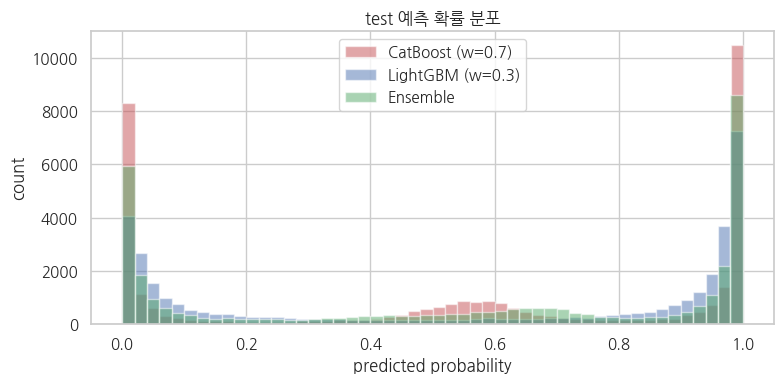

In [41]:
# 9-1. CatBoost test 예측
cat_test_pool = make_catboost_pool(X_test, None, CAT_COLS)
proba_cat_test = cat_model_full.predict_proba(cat_test_pool)[:, 1]

# 9-2. LightGBM test 예측
proba_lgb_test = lgb_model_full.predict(X_test_lgb_full)

# 9-3. 가중 앙상블
proba_final = W_LGB * proba_lgb_test + (1 - W_LGB) * proba_cat_test

print('test 예측 분포:')
print(f'  CatBoost  proba: min={proba_cat_test.min():.4f}, max={proba_cat_test.max():.4f}, mean={proba_cat_test.mean():.4f}')
print(f'  LightGBM  proba: min={proba_lgb_test.min():.4f}, max={proba_lgb_test.max():.4f}, mean={proba_lgb_test.mean():.4f}')
print(f'  Ensemble  proba: min={proba_final.min():.4f}, max={proba_final.max():.4f}, mean={proba_final.mean():.4f}')

# 분포 비교 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(proba_cat_test, bins=50, alpha=0.5, label=f'CatBoost (w={1-W_LGB:.1f})', color='#C44E52')
ax.hist(proba_lgb_test, bins=50, alpha=0.5, label=f'LightGBM (w={W_LGB:.1f})', color='#4C72B0')
ax.hist(proba_final, bins=50, alpha=0.5, label='Ensemble', color='#55A868')
ax.set_xlabel('predicted probability'); ax.set_ylabel('count')
ax.set_title('test 예측 확률 분포'); ax.legend()
plt.tight_layout(); plt.show()

## 10. submission.csv 생성 + 검증

### PDF 명시 규칙
- `id`: test.csv 그대로 동일 순서
- `Late_delivery_risk`: 0.0~1.0 확률값 (이진값 X)
- 36,104행
- .csv 형식

잘못했을까봐 검증 코드 포함

In [42]:
# 10-1. submission DataFrame 생성
submission = pd.DataFrame({
    'id': test_ids,
    'Late_delivery_risk': proba_final,
})

print('submission shape:', submission.shape)
print(submission.head())
print(submission.tail())

submission shape: (36104, 2)
       id  Late_delivery_risk
0   75083            0.008265
1   88208            0.003700
2  161090            0.047580
3  151346            0.028786
4  104796            0.991006
           id  Late_delivery_risk
36099   25551            0.497999
36100   55681            0.014601
36101  151639            0.095127
36102   81406            0.982552
36103  155905            0.964158


In [43]:
# 10-2. 제출 형식 검증 — assert로 강제 통과
N_EXPECTED = 36104

assert len(submission) == N_EXPECTED, \
    f'행 수 불일치: {len(submission):,} (기대 {N_EXPECTED:,})'
assert list(submission.columns) == ['id', 'Late_delivery_risk'], \
    f'컬럼 불일치: {list(submission.columns)}'
assert submission['Late_delivery_risk'].between(0, 1).all(), \
    '확률값 0~1 범위 밖 존재'
assert submission['Late_delivery_risk'].dtype.kind == 'f', \
    '확률값이 float가 아님'
assert (submission['id'].values == test_ids).all(), \
    'id 순서가 test와 다름'
assert submission['id'].is_unique, 'id 중복'

print('✓ 모든 제출 형식 조건 통과')
print(f'  - 행 수: {len(submission):,} (기대 {N_EXPECTED:,})')
print(f'  - 컬럼: {list(submission.columns)}')
print(f"  - 확률값 범위: [{submission['Late_delivery_risk'].min():.4f}, {submission['Late_delivery_risk'].max():.4f}]")
print(f"  - 확률값 평균: {submission['Late_delivery_risk'].mean():.4f}")
print(f'  - id 순서: test.csv와 동일')

✓ 모든 제출 형식 조건 통과
  - 행 수: 36,104 (기대 36,104)
  - 컬럼: ['id', 'Late_delivery_risk']
  - 확률값 범위: [0.0004, 0.9997]
  - 확률값 평균: 0.5601
  - id 순서: test.csv와 동일


In [44]:
# 10-3. 저장
submission.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8')
print(f'\n저장 완료: {SUBMISSION_PATH}')
print(f'파일 크기: {pd.read_csv(SUBMISSION_PATH).shape}')

# 다시 읽어서 1차 검증 (저장이 깨지지 않았는지)
reloaded = pd.read_csv(SUBMISSION_PATH)
assert reloaded.shape == submission.shape, '저장 후 형태 불일치'
assert (reloaded['id'].values == submission['id'].values).all(), 'id 순서 변경됨'
print('✓ 저장된 파일 재검증 통과')


저장 완료: /content/drive/MyDrive/assignment/submission.csv
파일 크기: (36104, 2)
✓ 저장된 파일 재검증 통과


단독으로 쓸 때랑 비율 0.5로 해서 했을 때도 따로 저장

In [45]:
# #2 — CatBoost 단독
sub2 = pd.DataFrame({'id': test_ids, 'Late_delivery_risk': proba_cat_test})
sub2_path = SUBMISSION_PATH.replace('submission.csv', 'submission_catboost_only.csv')
sub2.to_csv(sub2_path, index=False)
print(f'#2 저장: {sub2_path}')

# #3 — 균등 앙상블
proba_avg = 0.5 * proba_lgb_test + 0.5 * proba_cat_test
sub3 = pd.DataFrame({'id': test_ids, 'Late_delivery_risk': proba_avg})
sub3_path = SUBMISSION_PATH.replace('submission.csv', 'submission_avg_blend.csv')
sub3.to_csv(sub3_path, index=False)
print(f'#3 저장: {sub3_path}')

#2 저장: /content/drive/MyDrive/assignment/submission_catboost_only.csv
#3 저장: /content/drive/MyDrive/assignment/submission_avg_blend.csv

3개 제출 파일 모두 준비 완료. Kaggle에 업로드 후 Public 점수를 보고 Private 반영 3개 선택.


## 12. 결과 요약

| 항목 | 값 |
|---|---|
| 검증(80/20 holdout) PR-AUC | (위 7번 셀의 `best_row['PR-AUC']` 참고) |
| CatBoost best_iter | (5번 셀의 `cat_best_iter`) |
| LightGBM best_iter | (6번 셀의 `lgb_best_iter`) |
| 앙상블 가중치 | `w_lgb = ` (7번 셀) |
